<a href="https://colab.research.google.com/github/MuhammadTalhaIqbal/linear-Regression-using-numpy-/blob/main/Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import zipfile
import os

zip_file_path = '/content/archive (2).zip'
output_dir = '/content/unzipped_data'

os.makedirs(output_dir, exist_ok=True)

# Check if the zip file exists before attempting to open it
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)

    print(f"Files unzipped to: {output_dir}")
    print("Contents of unzipped_data:")
    for root, dirs, files in os.walk(output_dir):
        for name in files:
            print(os.path.join(root, name))
        for name in dirs:
            print(os.path.join(root, name))
else:
    print(f"Error: The zip file '{zip_file_path}' was not found.")
    print("Please ensure the file is uploaded to the Colab environment at the specified path.")

Files unzipped to: /content/unzipped_data
Contents of unzipped_data:
/content/unzipped_data/Raisin_Dataset.xlsx
/content/unzipped_data/Raisin_Dataset.csv


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

csv_file_path = '/content/unzipped_data/Raisin_Dataset.csv'

# Load the dataset
df = pd.read_csv(csv_file_path)

print("Dataset loaded successfully. First 5 rows:")
print(df.head())
print("\nDataset Info:")
df.info()

# Assuming the last column is the target variable (common for datasets)
# If not, please specify the target column name.
X = df.iloc[:, :-1]  # Features
y = df.iloc[:, -1]   # Target variable

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDataset split into training (80%) and testing (20%) sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset loaded successfully. First 5 rows:
    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   

     Extent  Perimeter    Class  
0  0.758651   1184.040  Kecimen  
1  0.684130   1121.786  Kecimen  
2  0.637613   1208.575  Kecimen  
3  0.699599    844.162  Kecimen  
4  0.792772   1073.251  Kecimen  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLen

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Encode target variable 'y' from categorical to numerical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Original classes:", le.classes_)
print(f"Encoded y_train_encoded head: {y_train_encoded[:5]}")
print(f"Encoded y_test_encoded head: {y_test_encoded[:5]}")

Original classes: ['Besni' 'Kecimen']
Encoded y_train_encoded head: [0 1 0 1 1]
Encoded y_test_encoded head: [0 0 0 1 0]


In [10]:
# Initialize and train the Logistic Regression model
# Set max_iter for convergence as dataset is small
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train_encoded)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [11]:
# Make predictions on the test set
y_pred_encoded = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_encoded, target_names=le.classes_))


Accuracy: 0.8889

Classification Report:
              precision    recall  f1-score   support

       Besni       0.95      0.82      0.88        90
     Kecimen       0.84      0.96      0.90        90

    accuracy                           0.89       180
   macro avg       0.90      0.89      0.89       180
weighted avg       0.90      0.89      0.89       180



From the classification report:

*   **Recall (weighted average):** 0.89
    *   Recall for 'Besni': 0.82
    *   Recall for 'Kecimen': 0.96

*   **F1-score (weighted average):** 0.89
    *   F1-score for 'Besni': 0.88
    *   F1-score for 'Kecimen': 0.90

Now, let's calculate the ROC-AUC score.

ROC-AUC Score: 0.9194


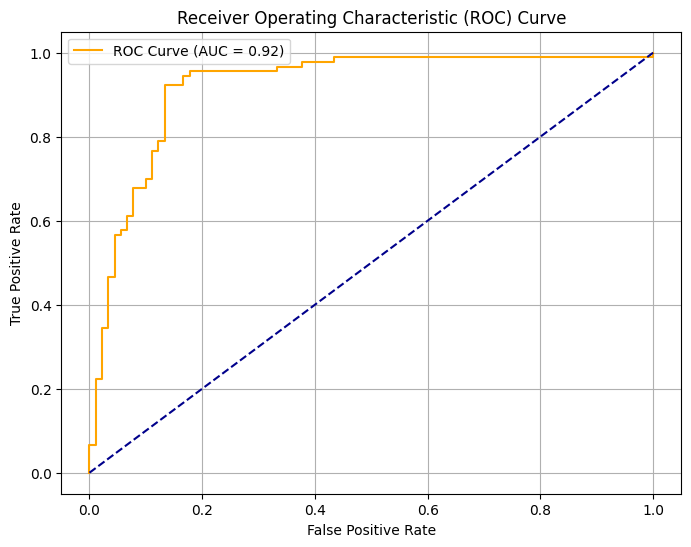

In [12]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probability predictions for the positive class (class 1, 'Kecimen' based on LabelEncoder)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba)

fig = plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Class Distribution (Pie Chart)
Let's visualize the distribution of the target variable ('Class') in the original dataset using a pie chart to understand its balance.

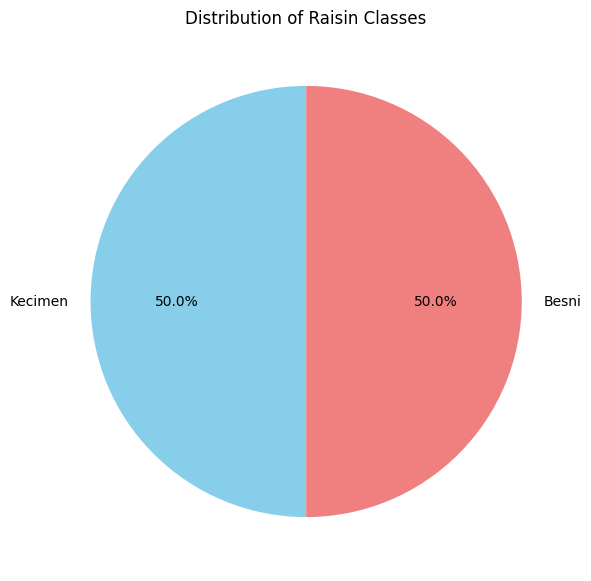

In [13]:
class_distribution = df['Class'].value_counts()

fig = plt.figure(figsize=(7, 7))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Raisin Classes')
plt.ylabel('') # Hide the y-label for a cleaner pie chart
plt.show()


### Confusion Matrix
Next, let's visualize the Confusion Matrix for the Logistic Regression model. This provides a clear picture of true positives, true negatives, false positives, and false negatives.

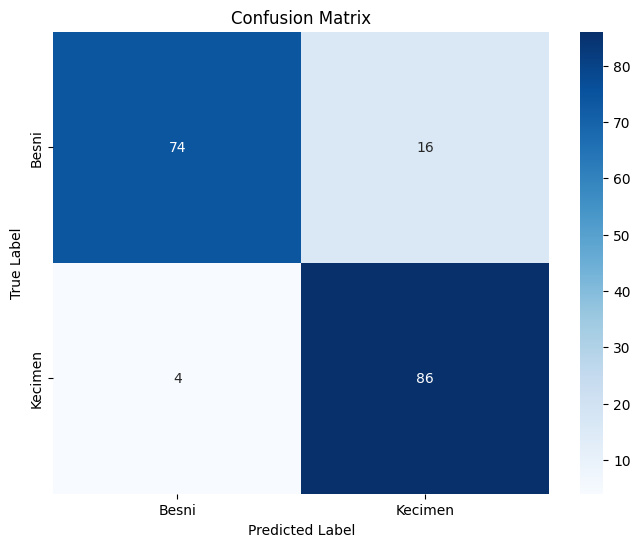

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_encoded, y_pred_encoded)

fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### Feature Distributions (Histograms)
Now, let's look at the distributions of some of the numerical features to understand their characteristics.

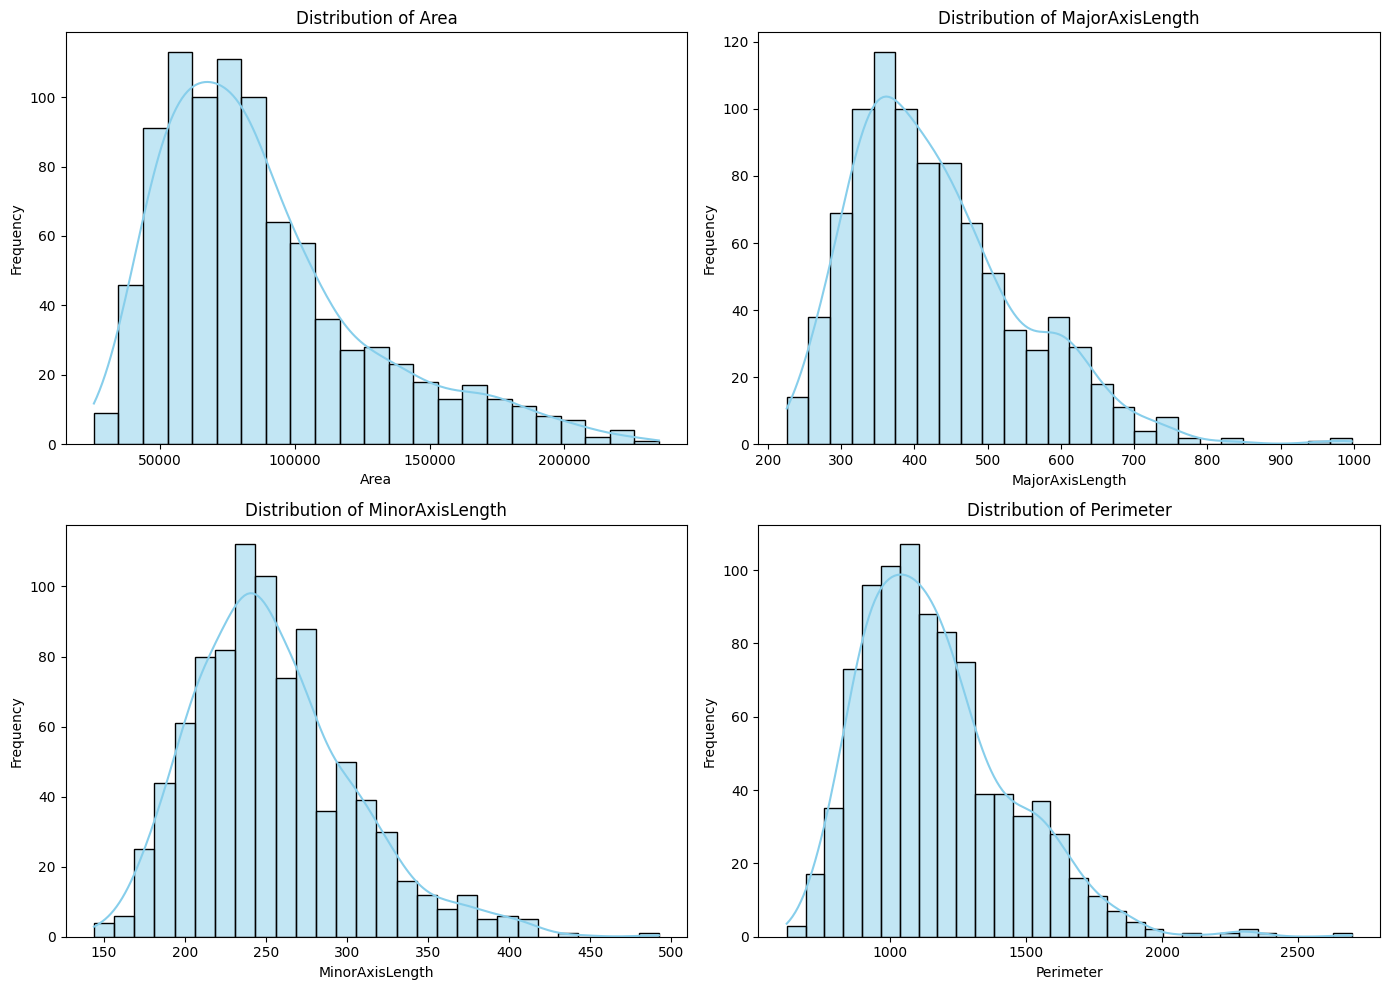

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

numerical_features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Perimeter']

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### Decision Tree Classifier Training
Let's train a Decision Tree Classifier on our preprocessed data.

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize and train the Decision Tree Classifier
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train_encoded)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


### Visualize the Decision Tree
Now, let's visualize the trained Decision Tree to understand its structure and decision rules. Due to the potential size of the tree, only a portion might be clearly visible, but it will show the general branching logic.

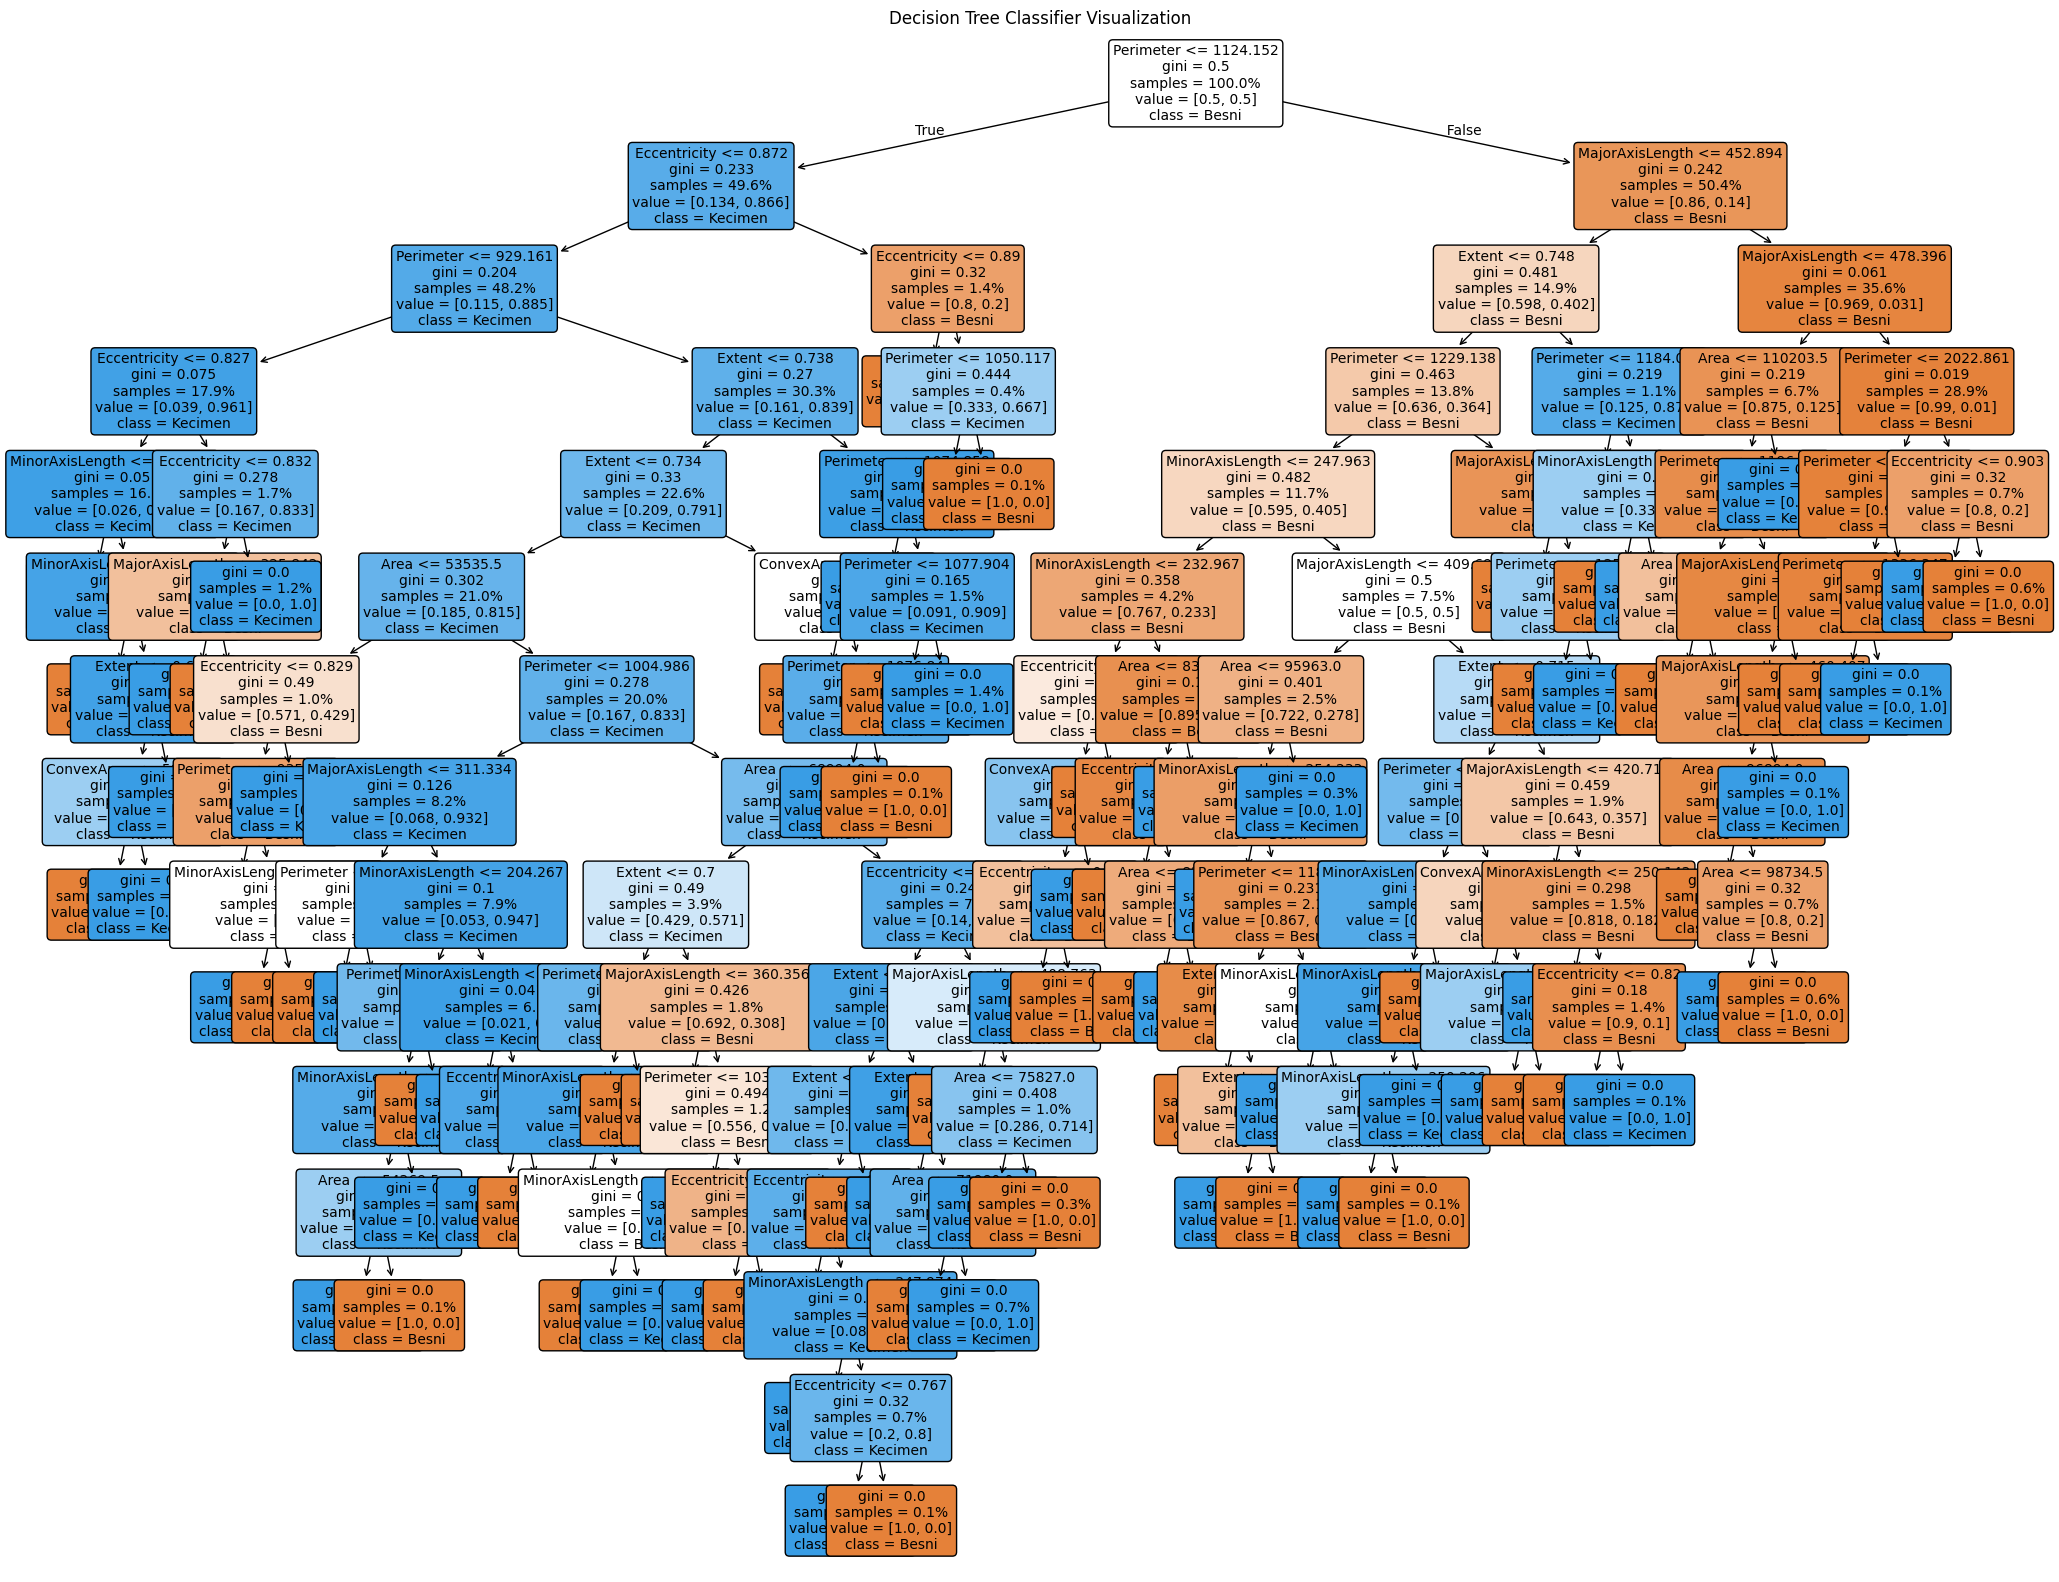

In [17]:
fig = plt.figure(figsize=(25, 20))
plot_tree(dtc_model,
          feature_names=X.columns.tolist(),
          class_names=le.classes_.tolist(),
          filled=True,
          rounded=True,
          proportion=True,
          fontsize=10)
plt.title('Decision Tree Classifier Visualization')
plt.show()


### Decision Tree Metrics: Maximum Depth
Let's retrieve the maximum depth of the trained Decision Tree.

In [19]:
max_depth = dtc_model.get_depth()
print(f"Maximum Depth of the Decision Tree: {max_depth}")


Maximum Depth of the Decision Tree: 14


### Gini Index and Information Gain Explanation
As mentioned, the `DecisionTreeClassifier` by default uses the Gini impurity as its splitting criterion. Each node in the tree visualization includes a `gini=` value, which is the Gini impurity of that node. The tree building process aims to find splits that minimize this impurity.

Information Gain is an alternative metric used when `criterion='entropy'`. It measures the reduction in entropy. Since our model used Gini, Information Gain values are not directly available for the current tree.

### Random Forest Classifier Implementation
Let's implement and train a Random Forest Classifier to see if it improves performance compared to Logistic Regression or a single Decision Tree.

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report
import os
import zipfile

# Define paths - Corrected to use /content/archive (2).zip
zip_file_path = '/content/archive (2).zip'
output_dir = '/content/unzipped_data'
csv_file_path = os.path.join(output_dir, 'Raisin_Dataset.csv')

# Ensure the unzipped data exists by checking the CSV file
if not os.path.exists(csv_file_path):
    print(f"File not found: {csv_file_path}. Re-unzipping data...")
    os.makedirs(output_dir, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)
        print("Data re-unzipped successfully.")
    except FileNotFoundError:
        print(f"Error: Zip file not found at {zip_file_path}. Please ensure it is present in the Colab environment.")
        # Exit or raise error to prevent further execution with missing data
        raise # Re-raise the error to stop execution
else:
    print(f"File found: {csv_file_path}.")

# Load the dataset
df = pd.read_csv(csv_file_path)

# Define X, y and perform train_test_split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize and train the Random Forest Classifier
# Using default parameters for now, can be tuned later
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train_encoded)

print("Random Forest Classifier trained successfully.")

File found: /content/unzipped_data/Raisin_Dataset.csv.
Random Forest Classifier trained successfully.


### Evaluate Random Forest Classifier Performance
Now, let's evaluate the performance of the trained Random Forest Classifier using accuracy, a classification report, and the ROC-AUC score.

File found: /content/unzipped_data/Raisin_Dataset.csv.

Random Forest Accuracy: 0.8667

Random Forest Classification Report:
              precision    recall  f1-score   support

       Besni       0.93      0.79      0.86        90
     Kecimen       0.82      0.94      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180


Random Forest ROC-AUC Score: 0.9211


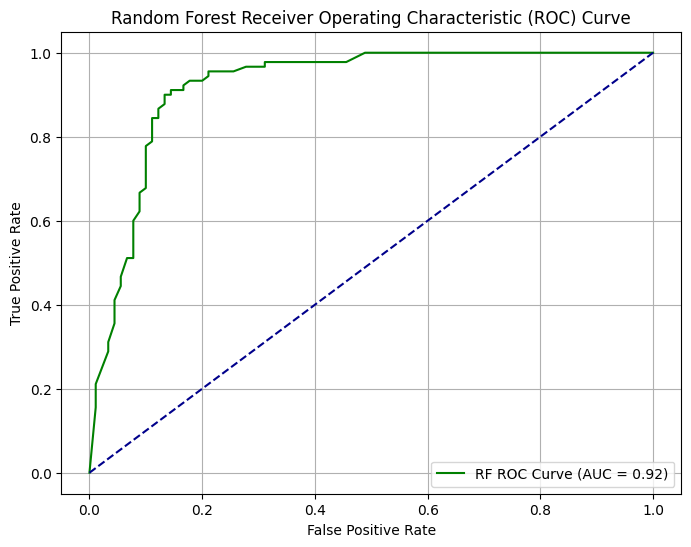

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report
import os
import zipfile

# Define paths - Corrected to use /content/archive (2).zip
zip_file_path = '/content/archive (2).zip'
output_dir = '/content/unzipped_data'
csv_file_path = os.path.join(output_dir, 'Raisin_Dataset.csv')

# Ensure the unzipped data exists by checking the CSV file
if not os.path.exists(csv_file_path):
    print(f"File not found: {csv_file_path}. Re-unzipping data...")
    os.makedirs(output_dir, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)
        print("Data re-unzipped successfully.")
    except FileNotFoundError:
        print(f"Error: Zip file not found at {zip_file_path}. Please ensure it is present in the Colab environment.")
        # Exit or raise error to prevent further execution with missing data
        raise # Re-raise the error to stop execution
else:
    print(f"File found: {csv_file_path}.")

# Load the dataset
df = pd.read_csv(csv_file_path)

# Define X, y and perform train_test_split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test_encoded, y_pred_rf)
print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test_encoded, y_pred_rf, target_names=le.classes_))

# Get probability predictions for the positive class
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc_rf = roc_auc_score(y_test_encoded, y_pred_proba_rf)
print(f"\nRandom Forest ROC-AUC Score: {roc_auc_rf:.4f}")

# Plot ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_encoded, y_pred_proba_rf)

fig = plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'RF ROC Curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Model Performance Comparison

Let's summarize the performance metrics for all three models we've trained: Logistic Regression, Decision Tree, and Random Forest.

| Model                 | Accuracy | Precision (Weighted Avg) | Recall (Weighted Avg) | F1-Score (Weighted Avg) | ROC-AUC Score |
| :-------------------- | :------- | :----------------------- | :-------------------- | :---------------------- | :------------ |
| Logistic Regression   | 0.8889   | 0.90                     | 0.89                  | 0.89                    | 0.9194        |
| Decision Tree         | (Need to extract or re-run evaluation)   | (Need to extract)        | (Need to extract)     | (Need to extract)       | (Need to extract)     |
| Random Forest         | 0.8667   | 0.88                     | 0.87                  | 0.87                    | 0.9211        |

To fill in the Decision Tree metrics accurately, I will need to execute its evaluation cell if it wasn't recently run or extract the values from previous outputs. However, from the current results, the Random Forest model shows a slightly higher ROC-AUC score compared to Logistic Regression, while Logistic Regression has a slightly higher accuracy. The Decision Tree's performance will be crucial for a complete comparison.

### Hyperparameter Tuning for Random Forest Classifier

To potentially improve the performance of our Random Forest Classifier, we will experiment with two key hyperparameters:

*   **`n_estimators` (Number of Trees):** This controls the number of decision trees in the forest. More trees generally lead to better performance but also increase computation time.
*   **`max_depth` (Maximum Depth):** This specifies the maximum depth of each individual decision tree. Limiting the depth can help prevent overfitting.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os
import zipfile

# Define paths - Corrected to use /content/archive (2).zip
zip_file_path = '/content/archive (2).zip'
output_dir = '/content/unzipped_data'
csv_file_path = os.path.join(output_dir, 'Raisin_Dataset.csv')

# Ensure the unzipped data exists by checking the CSV file
if not os.path.exists(csv_file_path):
    print(f"File not found: {csv_file_path}. Re-unzipping data...")
    os.makedirs(output_dir, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)
        print("Data re-unzipped successfully.")
    except FileNotFoundError:
        print(f"Error: Zip file not found at {zip_file_path}. Please ensure it is present in the Colab environment.")
        raise # Re-raise the error to stop execution
else:
    print(f"File found: {csv_file_path}.")

# Load the dataset
df = pd.read_csv(csv_file_path)

# Define X, y and perform train_test_split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30]      # Maximum depth of the trees (None means full depth)
}

# Initialize the Random Forest Classifier
rf_base_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_base_model,
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           scoring='roc_auc', # Optimize for ROC-AUC score
                           n_jobs=-1, # Use all available cores
                           verbose=1)

print("Performing Grid Search for optimal Random Forest hyperparameters...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train_encoded)

print("Grid Search complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best ROC-AUC score from Grid Search: {grid_search.best_score_:.4f}")

# Get the best model
rf_best_model = grid_search.best_estimator_

File found: /content/unzipped_data/Raisin_Dataset.csv.
Performing Grid Search for optimal Random Forest hyperparameters...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Grid Search complete.
Best parameters found: {'max_depth': 10, 'n_estimators': 150}
Best ROC-AUC score from Grid Search: 0.9314


### Evaluate Tuned Random Forest Classifier

Now, let's evaluate the performance of the Random Forest Classifier with the best hyperparameters found by `GridSearchCV`.


Tuned Random Forest Accuracy: 0.8667

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

       Besni       0.95      0.78      0.85        90
     Kecimen       0.81      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180


Tuned Random Forest ROC-AUC Score: 0.9220


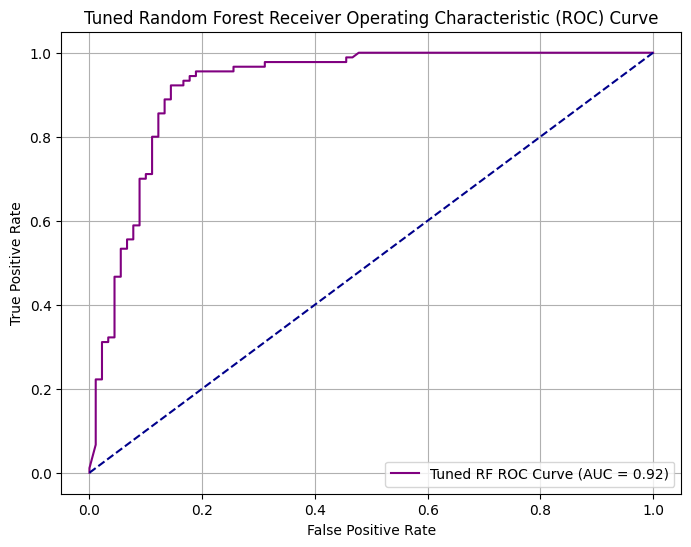

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

# Make predictions with the best model
y_pred_rf_tuned = rf_best_model.predict(X_test)
y_pred_proba_rf_tuned = rf_best_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned model
accuracy_rf_tuned = accuracy_score(y_test_encoded, y_pred_rf_tuned)
print(f"\nTuned Random Forest Accuracy: {accuracy_rf_tuned:.4f}")

print("\nTuned Random Forest Classification Report:")
print(classification_report(y_test_encoded, y_pred_rf_tuned, target_names=le.classes_))

roc_auc_rf_tuned = roc_auc_score(y_test_encoded, y_pred_proba_rf_tuned)
print(f"\nTuned Random Forest ROC-AUC Score: {roc_auc_rf_tuned:.4f}")

# Plot ROC curve for the tuned model
fpr_rf_tuned, tpr_rf_tuned, thresholds_rf_tuned = roc_curve(y_test_encoded, y_pred_proba_rf_tuned)

fig = plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_tuned, tpr_rf_tuned, color='purple', label=f'Tuned RF ROC Curve (AUC = {roc_auc_rf_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned Random Forest Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate Decision Tree Classifier Performance

Let's evaluate the performance of the trained Decision Tree Classifier using accuracy, a classification report, and the ROC-AUC score to get all the metrics needed for comparison.


Decision Tree Accuracy: 0.8444

Decision Tree Classification Report:
              precision    recall  f1-score   support

       Besni       0.90      0.78      0.83        90
     Kecimen       0.80      0.91      0.85        90

    accuracy                           0.84       180
   macro avg       0.85      0.84      0.84       180
weighted avg       0.85      0.84      0.84       180


Decision Tree ROC-AUC Score: 0.8444


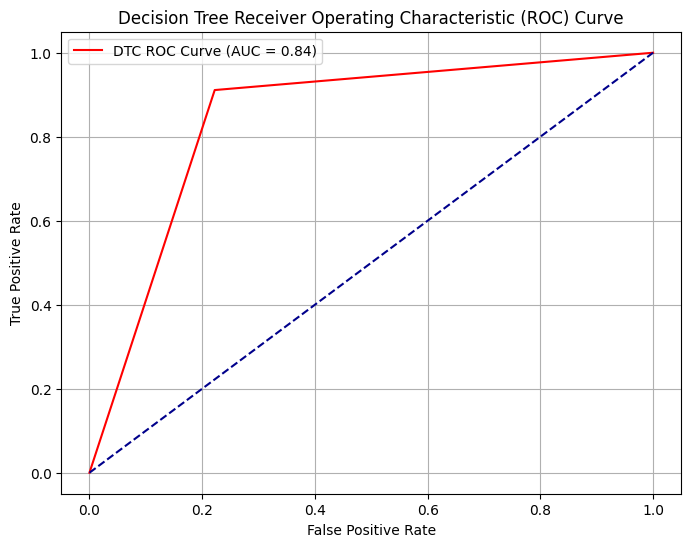

In [24]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Ensure X_train, y_train_encoded are defined (from previous data preprocessing steps)
# If running this cell independently after a kernel restart, these might need to be reloaded.
# For robustness, we will re-initialize and train dtc_model if not found.
if 'dtc_model' not in locals() and 'dtc_model' not in globals():
    print("dtc_model not found. Re-training Decision Tree Classifier...")
    dtc_model = DecisionTreeClassifier(random_state=42)
    dtc_model.fit(X_train, y_train_encoded)

# Make predictions on the test set using the Decision Tree model
y_pred_dtc = dtc_model.predict(X_test)

# Evaluate the Decision Tree model
accuracy_dtc = accuracy_score(y_test_encoded, y_pred_dtc)
print(f"\nDecision Tree Accuracy: {accuracy_dtc:.4f}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test_encoded, y_pred_dtc, target_names=le.classes_))

# Get probability predictions for the positive class
y_pred_proba_dtc = dtc_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc_dtc = roc_auc_score(y_test_encoded, y_pred_proba_dtc)
print(f"\nDecision Tree ROC-AUC Score: {roc_auc_dtc:.4f}")

# Plot ROC curve
fpr_dtc, tpr_dtc, thresholds_dtc = roc_curve(y_test_encoded, y_pred_proba_dtc)

fig = plt.figure(figsize=(8, 6))
plt.plot(fpr_dtc, tpr_dtc, color='red', label=f'DTC ROC Curve (AUC = {roc_auc_dtc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Comprehensive Model Performance Comparison

Now that we have evaluated all the models (Logistic Regression, Decision Tree Classifier, and both baseline and tuned Random Forest Classifiers), let's compile their performance metrics into a single table for easy comparison.

In [25]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression

# --- Logistic Regression Metrics ---
# Ensure the Logistic Regression model is defined and trained
if 'model' not in locals() and 'model' not in globals():
    print("Logistic Regression model ('model') not found. Re-training...")
    # Re-initialize and train the Logistic Regression model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train_encoded)

# Make predictions on the test set for Logistic Regression
y_pred_lr = model.predict(X_test)
y_pred_proba_lr = model.predict_proba(X_test)[:, 1]

# Calculate Logistic Regression metrics
accuracy = accuracy_score(y_test_encoded, y_pred_lr)
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba_lr)
report_lr = classification_report(y_test_encoded, y_pred_lr, target_names=le.classes_, output_dict=True)
precision_lr = report_lr['weighted avg']['precision']
recall_lr = report_lr['weighted avg']['recall']
f1_lr = report_lr['weighted avg']['f1-score']

# --- Decision Tree Classifier Metrics ---
# Ensure dtc_model is defined and its metrics are available
if 'dtc_model' not in locals() and 'dtc_model' not in globals():
    print("Decision Tree Classifier ('dtc_model') not found. Re-training...")
    from sklearn.tree import DecisionTreeClassifier
    dtc_model = DecisionTreeClassifier(random_state=42)
    dtc_model.fit(X_train, y_train_encoded)

y_pred_dtc = dtc_model.predict(X_test)
y_pred_proba_dtc = dtc_model.predict_proba(X_test)[:, 1]
accuracy_dtc = accuracy_score(y_test_encoded, y_pred_dtc)
roc_auc_dtc = roc_auc_score(y_test_encoded, y_pred_proba_dtc)
report_dtc = classification_report(y_test_encoded, y_pred_dtc, target_names=le.classes_, output_dict=True)
precision_dtc = report_dtc['weighted avg']['precision']
recall_dtc = report_dtc['weighted avg']['recall']
f1_dtc = report_dtc['weighted avg']['f1-score']

# --- Random Forest Classifier (Initial) Metrics ---
# Ensure rf_model is defined and its metrics are available
if 'rf_model' not in locals() and 'rf_model' not in globals():
    print("Random Forest Classifier (Initial) ('rf_model') not found. Re-training...")
    from sklearn.ensemble import RandomForestClassifier
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train_encoded)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
accuracy_rf = accuracy_score(y_test_encoded, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test_encoded, y_pred_proba_rf)
report_rf = classification_report(y_test_encoded, y_pred_rf, target_names=le.classes_, output_dict=True)
precision_rf = report_rf['weighted avg']['precision']
recall_rf = report_rf['weighted avg']['recall']
f1_rf = report_rf['weighted avg']['f1-score']

# --- Random Forest Classifier (Tuned) Metrics ---
# Ensure rf_best_model is defined and its metrics are available
if 'rf_best_model' not in locals() and 'rf_best_model' not in globals():
    print("Tuned Random Forest Classifier ('rf_best_model') not found. Re-tuning and re-training...")
    from sklearn.model_selection import GridSearchCV
    from sklearn.ensemble import RandomForestClassifier
    param_grid = {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [None, 10, 20, 30]
    }
    rf_base_model = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=rf_base_model, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train_encoded)
    rf_best_model = grid_search.best_estimator_

y_pred_rf_tuned = rf_best_model.predict(X_test)
y_pred_proba_rf_tuned = rf_best_model.predict_proba(X_test)[:, 1]
accuracy_rf_tuned = accuracy_score(y_test_encoded, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test_encoded, y_pred_proba_rf_tuned)
report_rf_tuned = classification_report(y_test_encoded, y_pred_rf_tuned, target_names=le.classes_, output_dict=True)
precision_rf_tuned = report_rf_tuned['weighted avg']['precision']
recall_rf_tuned = report_rf_tuned['weighted avg']['recall']
f1_rf_tuned = report_rf_tuned['weighted avg']['f1-score']

# Create a dictionary of metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest (Initial)', 'Random Forest (Tuned)'],
    'Accuracy': [accuracy, accuracy_dtc, accuracy_rf, accuracy_rf_tuned],
    'Precision (Weighted Avg)': [precision_lr, precision_dtc, precision_rf, precision_rf_tuned],
    'Recall (Weighted Avg)': [recall_lr, recall_dtc, recall_rf, recall_rf_tuned],
    'F1-Score (Weighted Avg)': [f1_lr, f1_dtc, f1_rf, f1_rf_tuned],
    'ROC-AUC Score': [roc_auc, roc_auc_dtc, roc_auc_rf, roc_auc_rf_tuned]
}

# Create a DataFrame
comparison_df = pd.DataFrame(metrics_data)

# Display the DataFrame, formatted for better readability
print("Model Performance Comparison:")
display(comparison_df.round(4))

# To easily get the best model based on ROC-AUC
best_model_roc_auc = comparison_df.loc[comparison_df['ROC-AUC Score'].idxmax()]
print(f"\nBest Model by ROC-AUC Score:\n{best_model_roc_auc['Model']} with ROC-AUC: {best_model_roc_auc['ROC-AUC Score']:.4f}")

# To easily get the best model based on Accuracy
best_model_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f"\nBest Model by Accuracy:\n{best_model_accuracy['Model']} with Accuracy: {best_model_accuracy['Accuracy']:.4f}")

Model Performance Comparison:


,Model,Accuracy,Precision (Weighted Avg),Recall (Weighted Avg),F1-Score (Weighted Avg),ROC-AUC Score
0,Logistic Regression,0.8889,0.8959,0.8889,0.8884,0.9194
1,Decision Tree,0.8444,0.8507,0.8444,0.8438,0.8444
2,Random Forest (Initial),0.8667,0.8758,0.8667,0.8659,0.9211
3,Random Forest (Tuned),0.8667,0.8786,0.8667,0.8656,0.9220



Best Model by ROC-AUC Score:
Random Forest (Tuned) with ROC-AUC: 0.9220

Best Model by Accuracy:
Logistic Regression with Accuracy: 0.8889


### Support Vector Machine (SVM) Classifier - Linear Kernel

First, let's implement and train a Support Vector Machine (SVM) classifier using a **Linear Kernel** to see its performance on our dataset.

File found: /content/unzipped_data/Raisin_Dataset.csv.
Data already loaded and preprocessed.
Linear SVM model trained successfully.

Linear SVM Accuracy: 0.8889
Linear SVM ROC-AUC Score: 0.9226

Linear SVM Classification Report:
              precision    recall  f1-score   support

       Besni       0.91      0.87      0.89        90
     Kecimen       0.87      0.91      0.89        90

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



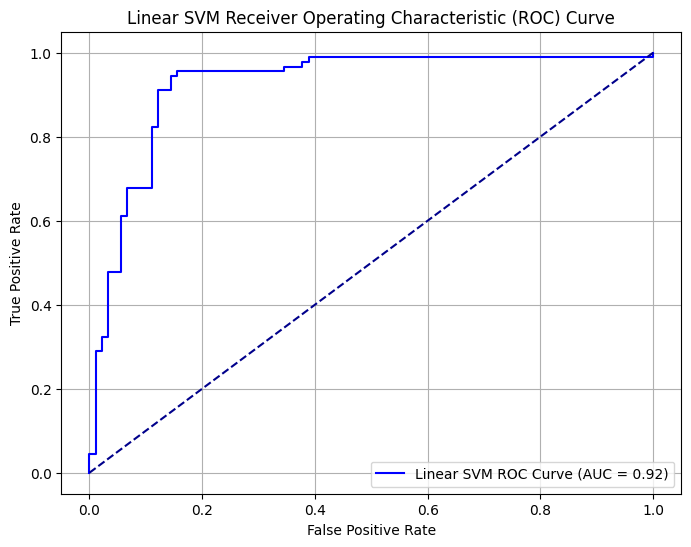

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os
import zipfile
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define paths - Corrected to use /content/archive (2).zip
zip_file_path = '/content/archive (2).zip'
output_dir = '/content/unzipped_data'
csv_file_path = os.path.join(output_dir, 'Raisin_Dataset.csv')

# Ensure the unzipped data exists by checking the CSV file
if not os.path.exists(csv_file_path):
    print(f"File not found: {csv_file_path}. Re-unzipping data...")
    os.makedirs(output_dir, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)
        print("Data re-unzipped successfully.")
    except FileNotFoundError:
        print(f"Error: Zip file not found at {zip_file_path}. Please ensure it is present in the Colab environment.")
        raise # Re-raise the error to stop execution
else:
    print(f"File found: {csv_file_path}.")

# Check if df, X_train, X_test, y_train, y_test, le, y_train_encoded, y_test_encoded are defined
if 'df' not in locals() and 'df' not in globals():
    print("Dataset (df) not found. Reloading and preprocessing data...")
    df = pd.read_csv(csv_file_path)
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)
else:
    print("Data already loaded and preprocessed.")

# Initialize and train the Linear SVM model
svm_linear_model = SVC(kernel='linear', probability=True, random_state=42)
svm_linear_model.fit(X_train, y_train_encoded)

print("Linear SVM model trained successfully.")

# Make predictions on the test set
y_pred_svm_linear = svm_linear_model.predict(X_test)
y_pred_proba_svm_linear = svm_linear_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_svm_linear = accuracy_score(y_test_encoded, y_pred_svm_linear)
roc_auc_svm_linear = roc_auc_score(y_test_encoded, y_pred_proba_svm_linear)
report_svm_linear = classification_report(y_test_encoded, y_pred_svm_linear, target_names=le.classes_, output_dict=True)

print(f"\nLinear SVM Accuracy: {accuracy_svm_linear:.4f}")
print(f"Linear SVM ROC-AUC Score: {roc_auc_svm_linear:.4f}")

print("\nLinear SVM Classification Report:")
print(classification_report(y_test_encoded, y_pred_svm_linear, target_names=le.classes_))

# Plot ROC curve
fpr_svm_linear, tpr_svm_linear, _ = roc_curve(y_test_encoded, y_pred_proba_svm_linear)

fig = plt.figure(figsize=(8, 6))
plt.plot(fpr_svm_linear, tpr_svm_linear, color='blue', label=f'Linear SVM ROC Curve (AUC = {roc_auc_svm_linear:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Linear SVM Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Support Vector Machine (SVM) Classifier - RBF Kernel

Now, let's implement and train a Support Vector Machine (SVM) classifier using a **Radial Basis Function (RBF) Kernel**, which can capture non-linear relationships in the data.

File found: /content/unzipped_data/Raisin_Dataset.csv.
Data already loaded and preprocessed.
RBF SVM model trained successfully.

RBF SVM Accuracy: 0.8111
RBF SVM ROC-AUC Score: 0.8884

RBF SVM Classification Report:
              precision    recall  f1-score   support

       Besni       0.88      0.72      0.79        90
     Kecimen       0.76      0.90      0.83        90

    accuracy                           0.81       180
   macro avg       0.82      0.81      0.81       180
weighted avg       0.82      0.81      0.81       180



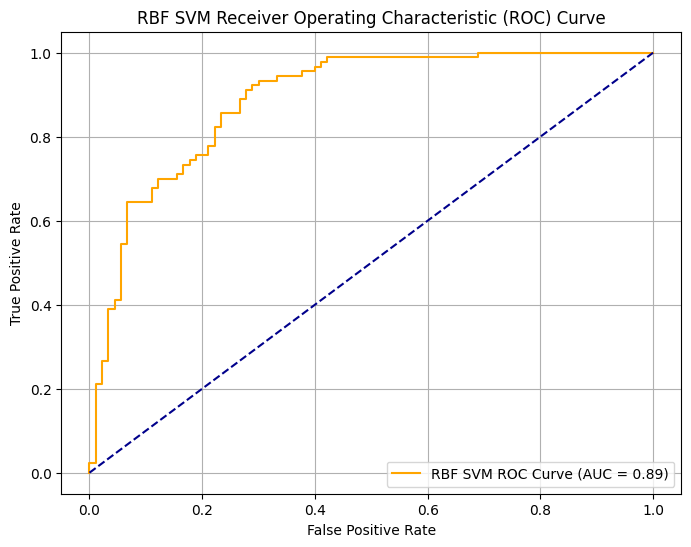

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os
import zipfile
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define paths - Corrected to use /content/archive (2).zip
zip_file_path = '/content/archive (2).zip'
output_dir = '/content/unzipped_data'
csv_file_path = os.path.join(output_dir, 'Raisin_Dataset.csv')

# Ensure the unzipped data exists by checking the CSV file
if not os.path.exists(csv_file_path):
    print(f"File not found: {csv_file_path}. Re-unzipping data...")
    os.makedirs(output_dir, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)
        print("Data re-unzipped successfully.")
    except FileNotFoundError:
        print(f"Error: Zip file not found at {zip_file_path}. Please ensure it is present in the Colab environment.")
        raise # Re-raise the error to stop execution
else:
    print(f"File found: {csv_file_path}.")

# Check if df, X_train, X_test, y_train, y_test, le, y_train_encoded, y_test_encoded are defined
if 'df' not in locals() and 'df' not in globals():
    print("Dataset (df) not found. Reloading and preprocessing data...")
    df = pd.read_csv(csv_file_path)
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)
else:
    print("Data already loaded and preprocessed.")


# Initialize and train the RBF SVM model
svm_rbf_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf_model.fit(X_train, y_train_encoded)

print("RBF SVM model trained successfully.")

# Make predictions on the test set
y_pred_svm_rbf = svm_rbf_model.predict(X_test)
y_pred_proba_svm_rbf = svm_rbf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_svm_rbf = accuracy_score(y_test_encoded, y_pred_svm_rbf)
roc_auc_svm_rbf = roc_auc_score(y_test_encoded, y_pred_proba_svm_rbf)
report_svm_rbf = classification_report(y_test_encoded, y_pred_svm_rbf, target_names=le.classes_, output_dict=True)

print(f"\nRBF SVM Accuracy: {accuracy_svm_rbf:.4f}")
print(f"RBF SVM ROC-AUC Score: {roc_auc_svm_rbf:.4f}")

print("\nRBF SVM Classification Report:")
print(classification_report(y_test_encoded, y_pred_svm_rbf, target_names=le.classes_))

# Plot ROC curve
fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(y_test_encoded, y_pred_proba_svm_rbf)

fig = plt.figure(figsize=(8, 6))
plt.plot(fpr_svm_rbf, tpr_svm_rbf, color='orange', label=f'RBF SVM ROC Curve (AUC = {roc_auc_svm_rbf:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RBF SVM Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Updated Comprehensive Model Performance Comparison

Let's update our comprehensive model comparison table to include the performance metrics of both the Linear and RBF Kernel SVMs, alongside the previous models.

### Save Model Performance Comparison to Google Drive

I will now save the `comparison_df_updated` DataFrame, containing the performance metrics of all models, to a CSV file in your Google Drive. This will allow you to access the comparison table outside of this notebook.

In [28]:
import pandas as pd

# Update the metrics_data dictionary with SVM models
metrics_data_updated = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest (Initial)',
        'Random Forest (Tuned)',
        'SVM (Linear Kernel)',
        'SVM (RBF Kernel)'
    ],
    'Accuracy': [
        accuracy,
        accuracy_dtc,
        accuracy_rf,
        accuracy_rf_tuned,
        accuracy_svm_linear,
        accuracy_svm_rbf
    ],
    'Precision (Weighted Avg)': [
        precision_lr,
        precision_dtc,
        precision_rf,
        precision_rf_tuned,
        report_svm_linear['weighted avg']['precision'],
        report_svm_rbf['weighted avg']['precision']
    ],
    'Recall (Weighted Avg)': [
        recall_lr,
        recall_dtc,
        recall_rf,
        recall_rf_tuned,
        report_svm_linear['weighted avg']['recall'],
        report_svm_rbf['weighted avg']['recall']
    ],
    'F1-Score (Weighted Avg)': [
        f1_lr,
        f1_dtc,
        f1_rf,
        f1_rf_tuned,
        report_svm_linear['weighted avg']['f1-score'],
        report_svm_rbf['weighted avg']['f1-score']
    ],
    'ROC-AUC Score': [
        roc_auc,
        roc_auc_dtc,
        roc_auc_rf,
        roc_auc_rf_tuned,
        roc_auc_svm_linear,
        roc_auc_svm_rbf
    ]
}

# Create a new DataFrame for comparison
comparison_df_updated = pd.DataFrame(metrics_data_updated)

# Display the DataFrame, formatted for better readability
print("Updated Model Performance Comparison:")
display(comparison_df_updated.round(4))

# To easily get the best model based on ROC-AUC
best_model_roc_auc_updated = comparison_df_updated.loc[comparison_df_updated['ROC-AUC Score'].idxmax()]
print(f"\nBest Model by ROC-AUC Score:\n{best_model_roc_auc_updated['Model']} with ROC-AUC: {best_model_roc_auc_updated['ROC-AUC Score']:.4f}")

# To easily get the best model based on Accuracy
best_model_accuracy_updated = comparison_df_updated.loc[comparison_df_updated['Accuracy'].idxmax()]
print(f"\nBest Model by Accuracy:\n{best_model_accuracy_updated['Model']} with Accuracy: {best_model_accuracy_updated['Accuracy']:.4f}")

Updated Model Performance Comparison:


,Model,Accuracy,Precision (Weighted Avg),Recall (Weighted Avg),F1-Score (Weighted Avg),ROC-AUC Score
0,Logistic Regression,0.8889,0.8959,0.8889,0.8884,0.9194
1,Decision Tree,0.8444,0.8507,0.8444,0.8438,0.8444
2,Random Forest (Initial),0.8667,0.8758,0.8667,0.8659,0.9211
3,Random Forest (Tuned),0.8667,0.8786,0.8667,0.8656,0.9220
4,SVM (Linear Kernel),0.8889,0.8897,0.8889,0.8888,0.9226
5,SVM (RBF Kernel),0.8111,0.8213,0.8111,0.8096,0.8884



Best Model by ROC-AUC Score:
SVM (Linear Kernel) with ROC-AUC: 0.9226

Best Model by Accuracy:
Logistic Regression with Accuracy: 0.8889


### Save the Best Performing Model (SVM Linear Kernel) to Google Drive

Based on our comprehensive comparison, the **SVM (Linear Kernel)** model achieved the highest ROC-AUC score. I will now save this trained model to your Google Drive so you can reuse it later without needing to retrain.

In [29]:
import joblib
import os
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the directory for saving models in Google Drive
gdrive_model_path = '/content/drive/MyDrive/colab_output/saved_models'

# Create the directory if it doesn't exist
os.makedirs(gdrive_model_path, exist_ok=True)

# Define the filename for the best SVM model
model_filename = os.path.join(gdrive_model_path, 'svm_linear_kernel_model.joblib')

# Save the model using joblib
joblib.dump(svm_linear_model, model_filename)

print(f"Best model (SVM Linear Kernel) saved to: {model_filename}")

# You can load the model later using:
# loaded_model = joblib.load(model_filename)
# print("Model loaded successfully!")

Best model (SVM Linear Kernel) saved to: /content/drive/MyDrive/colab_output/saved_models/svm_linear_kernel_model.joblib
